Plot example signals from the raw files

In [1]:
import tifffile as tf
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio

These are two img.tif files converted with MATLAB or python

In [2]:
imgPy = tf.memmap(r"E:\L6 Experiments\L607T4\FOV3\SEDS_day10_FOV3_optoRec_LBC0\SEDS_day10_FOV3_optoRec_LBC0_img\imgPy.tif")
imgMat = tf.memmap(r"E:\L6 Experiments\L607T4\FOV3\SEDS_day10_FOV3_optoRec_LBC0\SEDS_day10_FOV3_optoRec_LBC0_img\imgMat.tif")

# load interpolated samples
intPy = sio.loadmat(r"E:\L6 Experiments\L607T4\FOV3\SEDS_day10_FOV3_optoRec_LBC0\SEDS_day10_FOV3_optoRec_LBC0_img\ledArtifactDataInterpPy.mat")
intMat = sio.loadmat(r"E:\L6 Experiments\L607T4\FOV3\SEDS_day10_FOV3_optoRec_LBC0\SEDS_day10_FOV3_optoRec_LBC0_img\ledArtifactDataInterp.mat")

In [7]:
pyArtifact = intPy['ledArtifact']
matArtifact = intMat['ledArtifact']-1
print("Python artifact index:",pyArtifact)
print("Matlab artifact index:",matArtifact.flatten())

Python artifact index: [[(array([[ 2535,  4224, 32212]], dtype=int64), array([], shape=(0, 0), dtype=int64), array([], shape=(0, 0), dtype=int64))]]
Matlab artifact index: [ 2535  4224 32212]


Matlabs version should have one extra sample at the end

In [8]:
print('pyImg:',imgPy.shape)
print('matImg',imgMat.shape)

pyImg: (39002, 512, 512)
matImg (39003, 512, 512)


Raw images

Text(0.5, 1.0, 'Py-Mat frame 100')

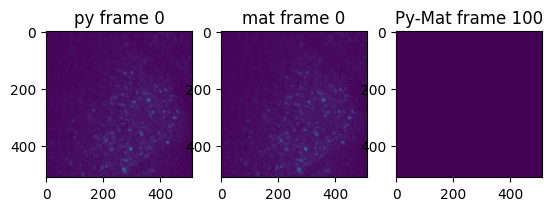

In [9]:
fig, ax = plt.subplots(nrows=1,ncols=3)
ax[0].imshow(imgPy[0]); ax[0].set_title("py frame 0")
ax[1].imshow(imgMat[0]); ax[1].set_title("mat frame 0")
ax[2].imshow(imgPy[100]-imgMat[100]); ax[2].set_title("Py-Mat frame 100")

Get max projection over time to compare datasets. Note that we exclude the last datapoint from the MATLAB img

In [10]:
maxPy = np.max(imgPy,axis=0)
maxMat = np.max(imgMat[:-1],axis=0)

The figure below should end up blank when subtracting the two max projection images. If so, then we know they operate similar enough.

Text(0.5, 1.0, 'Py-Mat max')

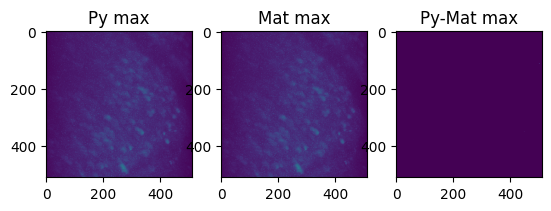

In [11]:
fig, ax = plt.subplots(nrows=1,ncols=3)
ax[0].imshow(maxPy); ax[0].set_title("Py max")
ax[1].imshow(maxMat); ax[1].set_title("Mat max")
ax[2].imshow(maxPy-maxMat); ax[2].set_title("Py-Mat max")

In [13]:
np.min(maxPy-maxMat)
#np.max(maxPy-maxMat)

0